# 🎓 Projeto Final - SCTEC 2026: Classificação de Dígitos Manuscritos
### Machine Learning, Deep Learning e Visão Computacional Aplicada ao MNIST

Este notebook consolida e documenta todo o projeto desenvolvido, cobrindo o ciclo completo de Ciência de Dados e Machine Learning:
1. **Fase 1: Carregamento e Análise Exploratória dos Dados (EDA)**
2. **Fase 2: Preparação e Pré-processamento dos Dados (Divisão Estratificada 70/15/15 e Normalização)**
3. **Fase 3: Treinamento e Ajuste dos Modelos de ML e Deep Learning (Random Forest, KNN, SVM, MLP e CNN Keras)**
4. **Fase 4: Avaliação Comparativa de Desempenho no Teste e Matrizes de Confusão**
5. **Fase 5: Testes de Robustez (Classes Ocultadas) e Pipeline OpenCV em Imagens Externas (Paint)**

---


## 🛠️ Configuração do Ambiente e Importação de Módulos


In [1]:
import os
import sys
import time
import glob
import joblib
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

# Habilita renderização gráfica inline
%matplotlib inline

# Garante que a raiz do repositório esteja no sys.path
caminho_projeto = os.path.abspath(".")
if caminho_projeto not in sys.path:
    sys.path.append(caminho_projeto)

# Importa os módulos desenvolvidos na pasta src/
from src.eda import (
    carregar_dados,
    inspecionar_dados,
    analisar_balanceamento,
    visualizar_exemplos_por_classe,
    visualizar_digito_medio,
    executar_eda_completo,
)
from src.preprocessing import (
    normalizar_pixels,
    dividir_dados_estratificado,
    verificar_estratificacao,
    plotar_divisao_classes,
    executar_preparacao_dados,
)
from src.models import (
    treinar_e_salvar_todos_modelos,
)
from src.evaluation import (
    carregar_modelos,
    avaliar_modelo,
    plotar_matrizes_confusao,
    plotar_comparativo_modelos,
    executar_avaliacao_completa,
)
from src.robustness import (
    testar_classes_ausentes,
    processar_imagem_externa_opencv,
    gerar_tabela_resultados_paint,
    testar_imagens_externas_todos_modelos,
    executar_fase_robustez_completa,
)

print("Todos os módulos e bibliotecas foram carregados com sucesso!")


Todos os módulos e bibliotecas foram carregados com sucesso!


## 📊 Fase 1: Carregamento e Análise Exploratória de Dados (EDA)

O dataset **MNIST** é composto por 70.000 imagens em escala de cinza de dígitos manuscritos (0 a 9) com resolução de 28x28 pixels (784 features).
Abaixo carregamos o conjunto e inspecionamos dimensões, integridade e amplitude dos valores de pixel.


In [2]:
# 1. Carregamento dos dados originais
X, y = carregar_dados()

# 2. Inspeção de dimensões e integridade (nulos)
stats = inspecionar_dados(X, y)



1. CARREGAMENTO DO DATASET MNIST
Carregando os dados (usando cache local se disponível)...
-> Carregamento concluído com sucesso!
-> Amostras totais: 70,000
-> Dimensão de cada amostra (vetor 1D): 784 pixels (28x28)

2. INSPEÇÃO E INTEGRIDADE DOS DADOS
- Formato da matriz X : (70000, 784) (int64)
- Formato do vetor y  : (70000,) (uint8)
- Classes detectadas  : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
- Valores ausentes X  : 0 nulos
- Valores ausentes y  : 0 nulos
- Intensidade do pixel:
    * Mínimo : 0.0
    * Máximo : 255.0
    * Média  : 33.39
    * Desvio : 78.65


### Análise de Balanceamento das Classes
Avaliamos a quantidade e a frequência de cada um dos 10 dígitos (0 a 9).



3. ANÁLISE DE BALANCEAMENTO DAS CLASSES
 Dígito  Quantidade  Percentual (%)
      0        6903            9.86
      1        7877           11.25
      2        6990            9.99
      3        7141           10.20
      4        6824            9.75
      5        6313            9.02
      6        6876            9.82
      7        7293           10.42
      8        6825            9.75
      9        6958            9.94

Diagnóstico de balanceamento:
- Menor classe: Dígito 5 com 6,313 amostras (9.02%)
- Maior classe: Dígito 1 com 7,877 amostras (11.25%)
- Razão Max/Min: 1.25 (Próximo de 1.0 indica classes bem balanceadas)
-> Gráfico de balanceamento salvo em: 'outputs/distribuicao_classes.png'


,Dígito,Quantidade,Percentual (%)
0,0,6903,9.86
1,1,7877,11.25
2,2,6990,9.99
3,3,7141,10.20
4,4,6824,9.75
5,5,6313,9.02
6,6,6876,9.82
7,7,7293,10.42
8,8,6825,9.75
9,9,6958,9.94


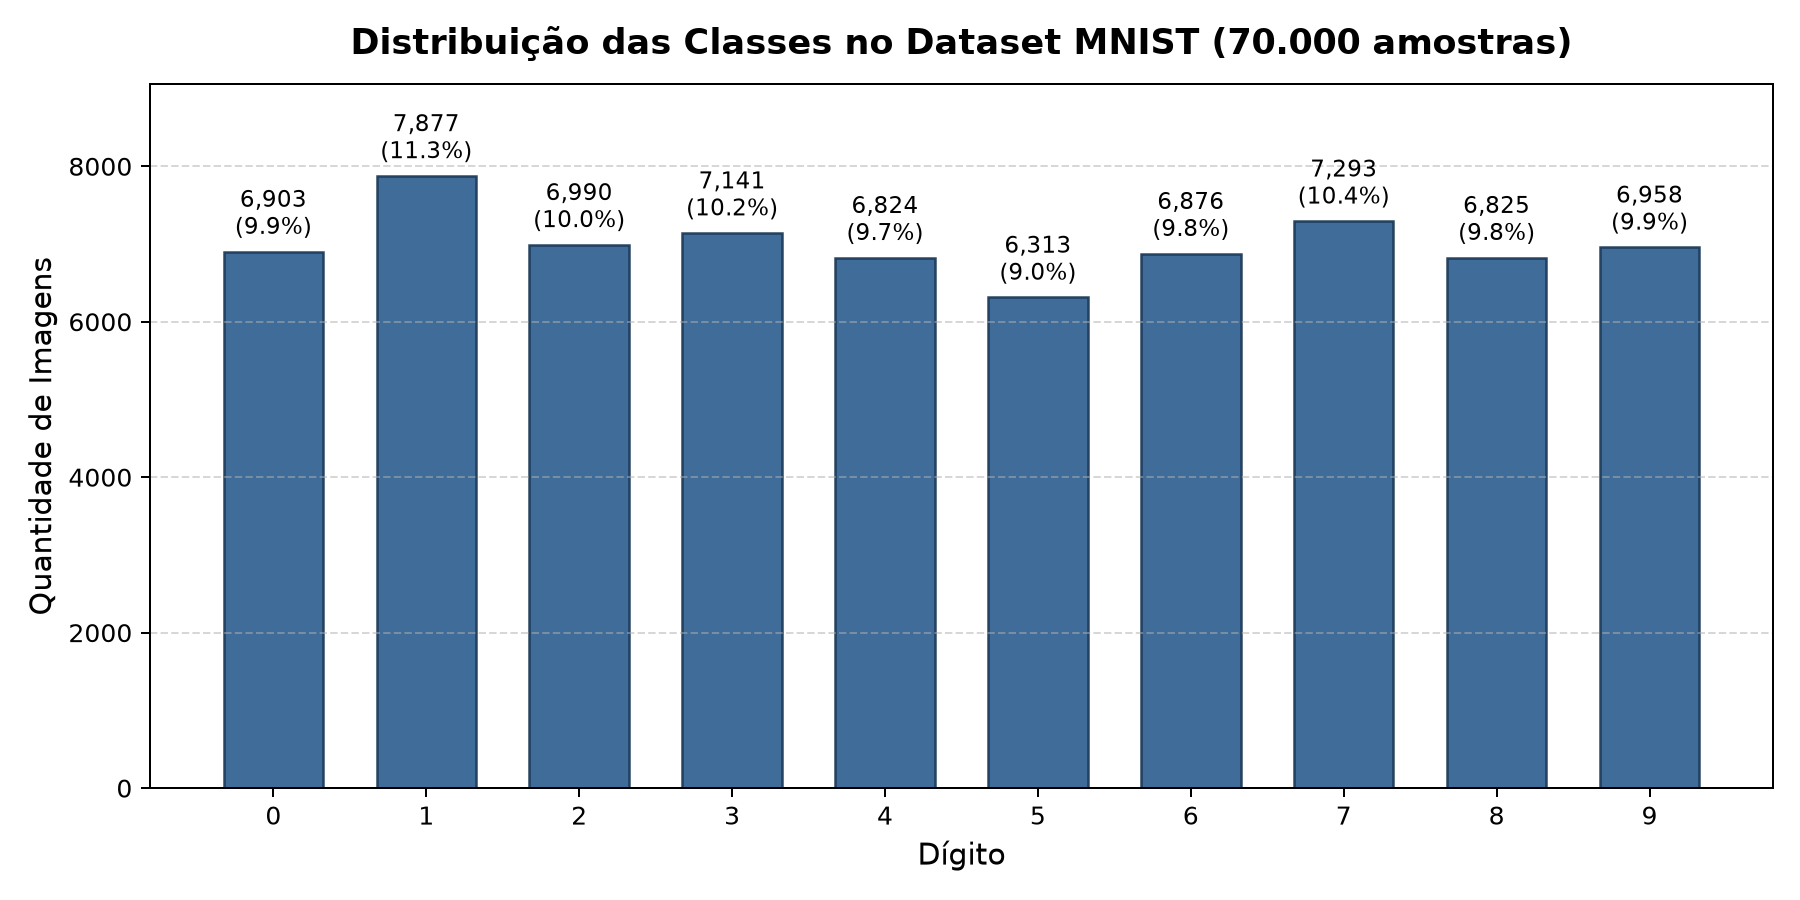

In [3]:
df_dist = analisar_balanceamento(y, salvar_grafico=True, caminho_saida="outputs/distribuicao_classes.png")
display(df_dist)
display(Image(filename="outputs/distribuicao_classes.png"))


### Visualização de Amostras Reais e Dígitos Médios (Centroides)
- **Amostras por classe**: visualização de exemplos reais com a variabilidade natural da escrita humana.
- **Dígito médio**: média pixel a pixel calculada para cada classe, evidenciando o traçado canônico.



4. VISUALIZAÇÃO DE AMOSTRAS POR CLASSE
-> Grid de amostras por classe salvo em: 'outputs/amostras_classes.png'


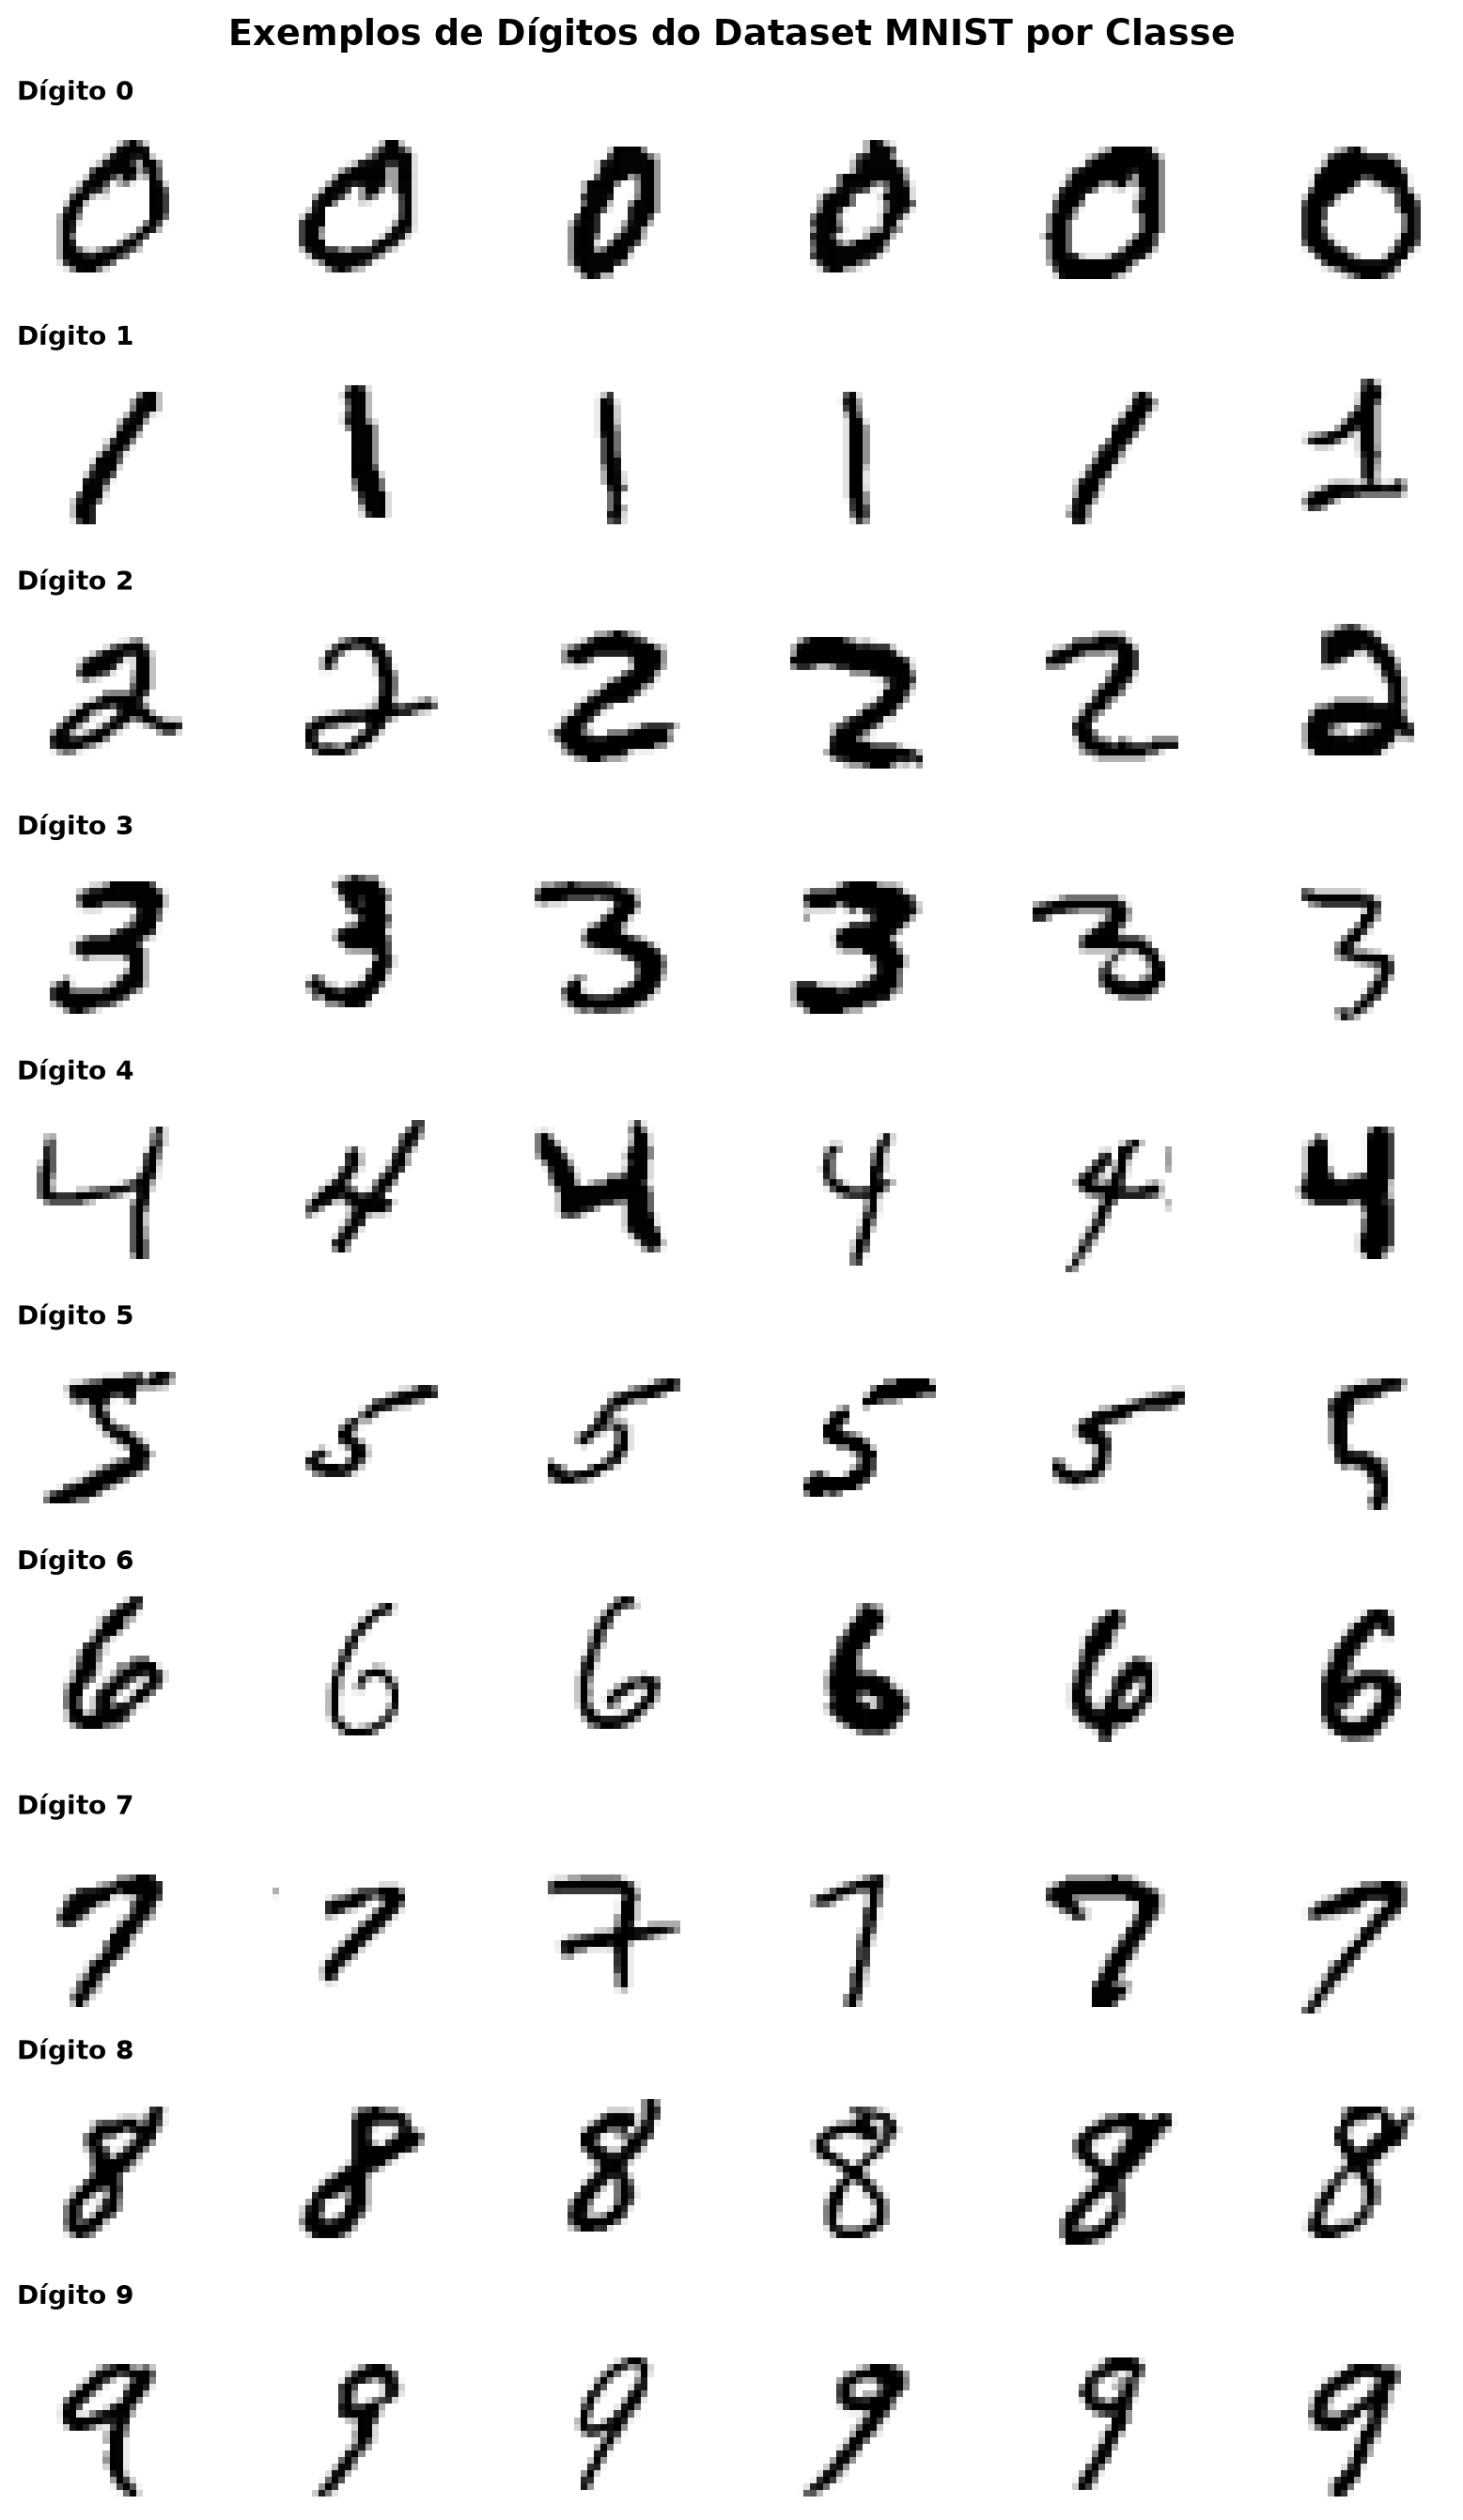


5. VISUALIZAÇÃO DOS DÍGITOS MÉDIOS (CENTROIDES)
-> Imagens dos dígitos médios salvas em: 'outputs/digitos_medios.png'


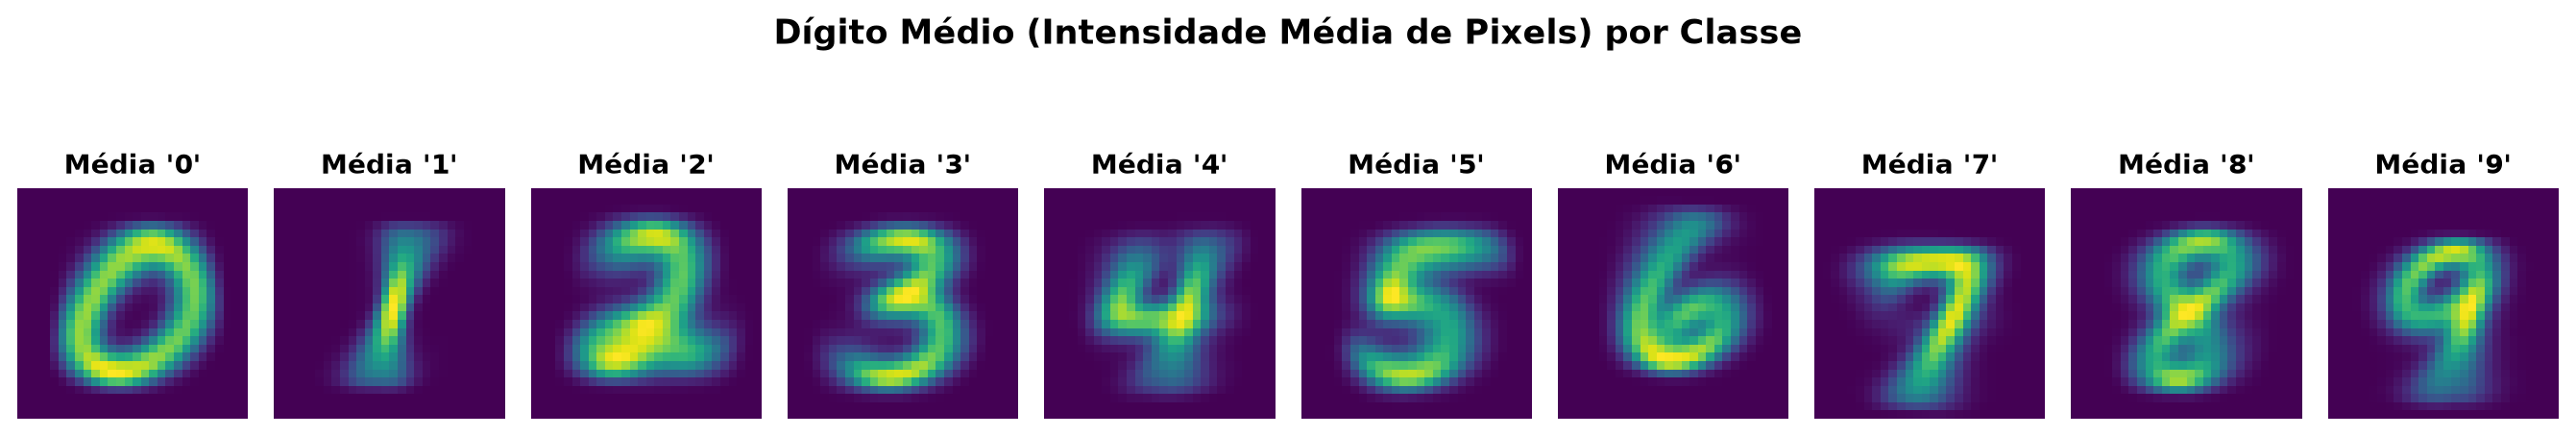

In [4]:
# Grid de amostras reais por dígito
visualizar_exemplos_por_classe(X, y, amostras_por_classe=6, salvar_grafico=True, caminho_saida="outputs/amostras_classes.png")
display(Image(filename="outputs/amostras_classes.png"))

# Dígitos Médios (Centroides)
visualizar_digito_medio(X, y, salvar_grafico=True, caminho_saida="outputs/digitos_medios.png")
display(Image(filename="outputs/digitos_medios.png"))


## ⚙️ Fase 2: Preparação e Pré-processamento dos Dados

Para garantir estabilidade numérica nos otimizadores e convergência adequada:
1. Normalizamos a escala dos pixels de `[0, 255]` para `[0.0, 1.0]` em `float32`.
2. Realizamos a divisão **estratificada** dos dados:
   - **Treino**: 70% (49.000 imagens)
   - **Validação**: 15% (10.500 imagens)
   - **Teste**: 15% (10.500 imagens)
3. Auditamos a preservação das proporções entre as partições.



Normalizando pixels para a escala [0.0, 1.0] (float32)...
-> Escala ajustada: Mínimo = 0.0, Máximo = 1.0

Dividindo dados (Total: 70,000 amostras):
- Teste: 15.0%
- Validação: 15.0%
- Treino: 70.0%
-> Divisão concluída:
    * Treino    : 49,000 amostras (70.0%) | Shape: (49000, 784)
    * Validação : 10,500 amostras (15.0%) | Shape: (10500, 784)
    * Teste     : 10,500 amostras (15.0%) | Shape: (10500, 784)

Auditoria de Estratificação (Proporção de Classes por Partição):
 Dígito  Treino (%)  Validação (%)  Teste (%)
      0        9.86           9.87       9.86
      1       11.25          11.25      11.26
      2        9.99           9.99       9.98
      3       10.20          10.20      10.20
      4        9.75           9.74       9.75
      5        9.02           9.02       9.02
      6        9.82           9.82       9.82
      7       10.42          10.42      10.42
      8        9.75           9.75       9.75
      9        9.94           9.94       9.94
-> Desvio máxim

,Dígito,Treino (%),Validação (%),Teste (%)
0,0,9.86,9.87,9.86
1,1,11.25,11.25,11.26
2,2,9.99,9.99,9.98
3,3,10.20,10.20,10.20
4,4,9.75,9.74,9.75
5,5,9.02,9.02,9.02
6,6,9.82,9.82,9.82
7,7,10.42,10.42,10.42
8,8,9.75,9.75,9.75
9,9,9.94,9.94,9.94


-> Gráfico comparativo da divisão salvo em: 'outputs/divisao_dados.png'


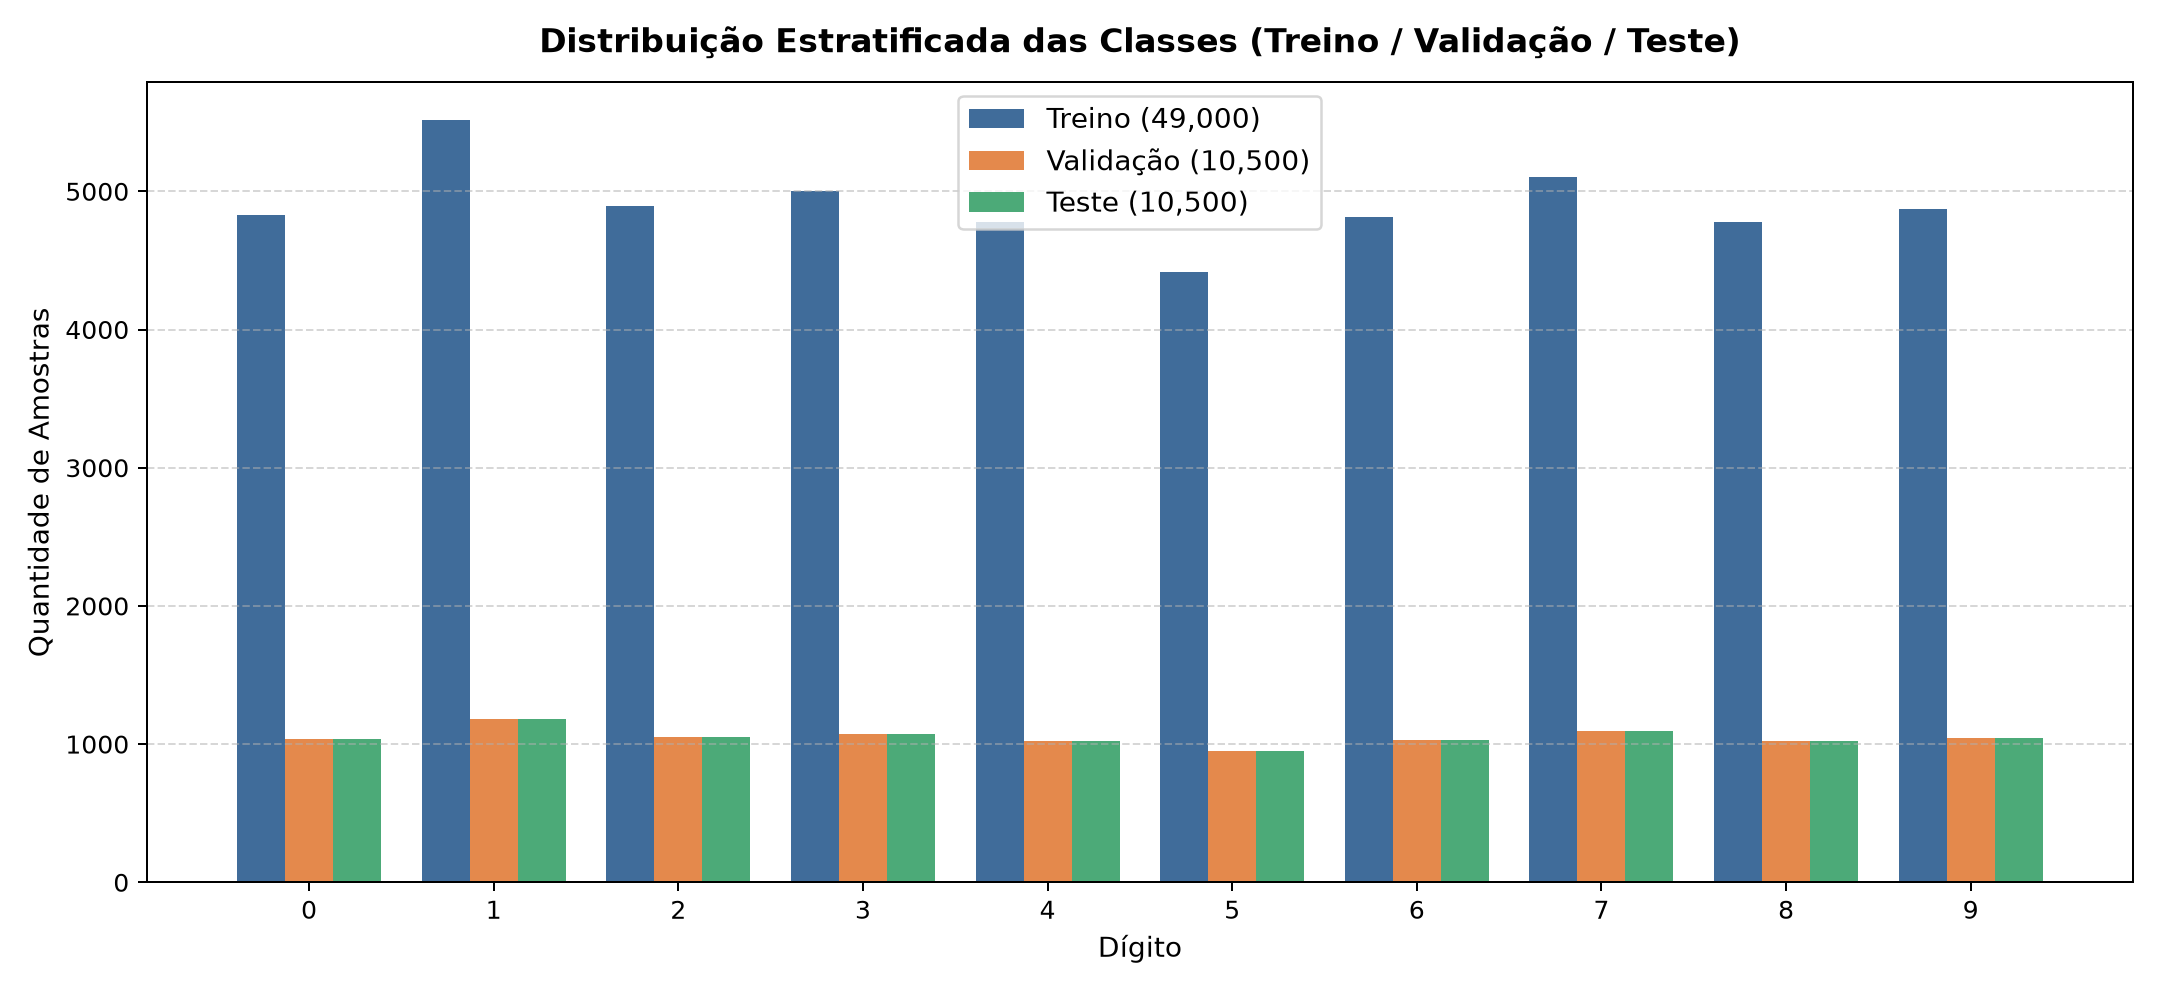

In [5]:
# 1. Normalização [0.0, 1.0]
X_norm = normalizar_pixels(X)

# 2. Divisão estratificada (70% treino, 15% validação, 15% teste)
X_train, X_val, X_test, y_train, y_val, y_test = dividir_dados_estratificado(
    X_norm,
    y,
    proporcao_teste=0.15,
    proporcao_val=0.15,
    random_state=42
)

# 3. Auditoria de estratificação
df_estrat = verificar_estratificacao(y_train, y_val, y_test)
display(df_estrat)

# 4. Gráfico da distribuição das partições
plotar_divisao_classes(y_train, y_val, y_test, caminho_saida="outputs/divisao_dados.png")
display(Image(filename="outputs/divisao_dados.png"))

# Estrutura unificada com os dados particionados
dados_preparados = {
    "X_train": X_train,
    "y_train": y_train,
    "X_val": X_val,
    "y_val": y_val,
    "X_test": X_test,
    "y_test": y_test,
}


## 🧠 Fase 3: Treinamento e Carregamento dos Modelos de ML

Comparamos 5 abordagens representativas de algoritmos:
- **Random Forest**: Ensemble não-linear baseado em bagging de 100 árvores.
- **K-Nearest Neighbors (KNN)**: Algoritmo baseado em instâncias com ponderação pela distância.
- **Support Vector Machine (SVM)**: Margens máximas com kernel RBF não-linear ($C=5.0$).
- **Rede Neural MLP**: Perceptron multicamadas totalmente conectado com ativação ReLU.
- **Rede Neural Convolucional (Keras CNN)**: Arquitetura com convolução 2D, pooling e dropout especializada em dados espaciais.

A célula abaixo verifica se os arquivos `.pkl` e `.keras` já existem na pasta `models/` e os reaproveita instantaneamente, ou executa o treinamento completo caso necessário.


In [6]:
modelos_esperados = ["random_forest.pkl", "knn.pkl", "svm.pkl", "mlp.pkl", "keras_cnn.keras"]
todos_existem = all(os.path.exists(os.path.join("models", m)) for m in modelos_esperados)

tempos_treino = {
    "Random Forest": 12.76,
    "KNN": 0.02,
    "SVM": 34.28,
    "Rede Neural MLP": 23.71,
    "Rede Neural Keras": 94.51,
}

if not todos_existem:
    print("Iniciando treinamento dos modelos...")
    info_modelos = treinar_e_salvar_todos_modelos(dados_preparados, diretorio_modelos="models")
    tempos_treino = {nome: info["tempo_treino"] for nome, info in info_modelos.items()}
    modelos = carregar_modelos("models")
else:
    print("-> Modelos pré-treinados encontrados na pasta 'models/'. Carregando...")
    modelos = carregar_modelos("models")

print(f"Modelos carregados com sucesso: {list(modelos.keys())}")


-> Modelos pré-treinados encontrados na pasta 'models/'. Carregando...

Carregando modelos do disco...
-> 'Random Forest' carregado com sucesso.
-> 'KNN' carregado com sucesso.
-> 'SVM' carregado com sucesso.
-> 'Rede Neural MLP' carregado com sucesso.
-> 'Rede Neural Keras' carregado com sucesso.
Modelos carregados com sucesso: ['Random Forest', 'KNN', 'SVM', 'Rede Neural MLP', 'Rede Neural Keras']


## 📈 Fase 4: Avaliação Comparativa de Desempenho no Teste

Avaliamos os 5 modelos no conjunto de teste independente (10.500 amostras).
Métricas calculadas:
- **Acurácia (%)**
- **Precisão, Recall e F1-score (Macro e Ponderado)**
- **Latência média de inferência por imagem (ms)**
- **Matrizes de Confusão**



FASE 4: AVALIAÇÃO DETALHADA E COMPARAÇÃO DOS MODELOS

Carregando modelos do disco...
-> 'Random Forest' carregado com sucesso.
-> 'KNN' carregado com sucesso.
-> 'SVM' carregado com sucesso.
-> 'Rede Neural MLP' carregado com sucesso.
-> 'Rede Neural Keras' carregado com sucesso.

--- Avaliando Random Forest no conjunto de Teste (10.500 amostras) ---
-> Acurácia : 96.63%
-> F1-Score : 96.63%
-> Precisão : 96.63%
-> Recall   : 96.63%
-> Tempo total de teste : 0.32s (0.031 ms/imagem)

--- Avaliando KNN no conjunto de Teste (10.500 amostras) ---
-> Acurácia : 97.12%
-> F1-Score : 97.12%
-> Precisão : 97.15%
-> Recall   : 97.12%
-> Tempo total de teste : 13.95s (1.328 ms/imagem)

--- Avaliando SVM no conjunto de Teste (10.500 amostras) ---
-> Acurácia : 97.26%
-> F1-Score : 97.25%
-> Precisão : 97.26%
-> Recall   : 97.26%
-> Tempo total de teste : 47.18s (4.494 ms/imagem)

--- Avaliando Rede Neural MLP no conjunto de Teste (10.500 amostras) ---
-> Acurácia : 97.47%
-> F1-Score : 97.47%
->

,Modelo,Acurácia (%),Precisão (%),Recall (%),F1-Score (%),Tempo Treino (s),Tempo Teste (s),Latência (ms/img)
0,Rede Neural Keras,98.97,98.98,98.97,98.97,94.51,2.69,0.257
1,Rede Neural MLP,97.47,97.47,97.47,97.47,23.71,0.05,0.005
2,SVM,97.26,97.26,97.26,97.25,34.28,47.18,4.494
3,KNN,97.12,97.15,97.12,97.12,0.02,13.95,1.328
4,Random Forest,96.63,96.63,96.63,96.63,12.76,0.32,0.031


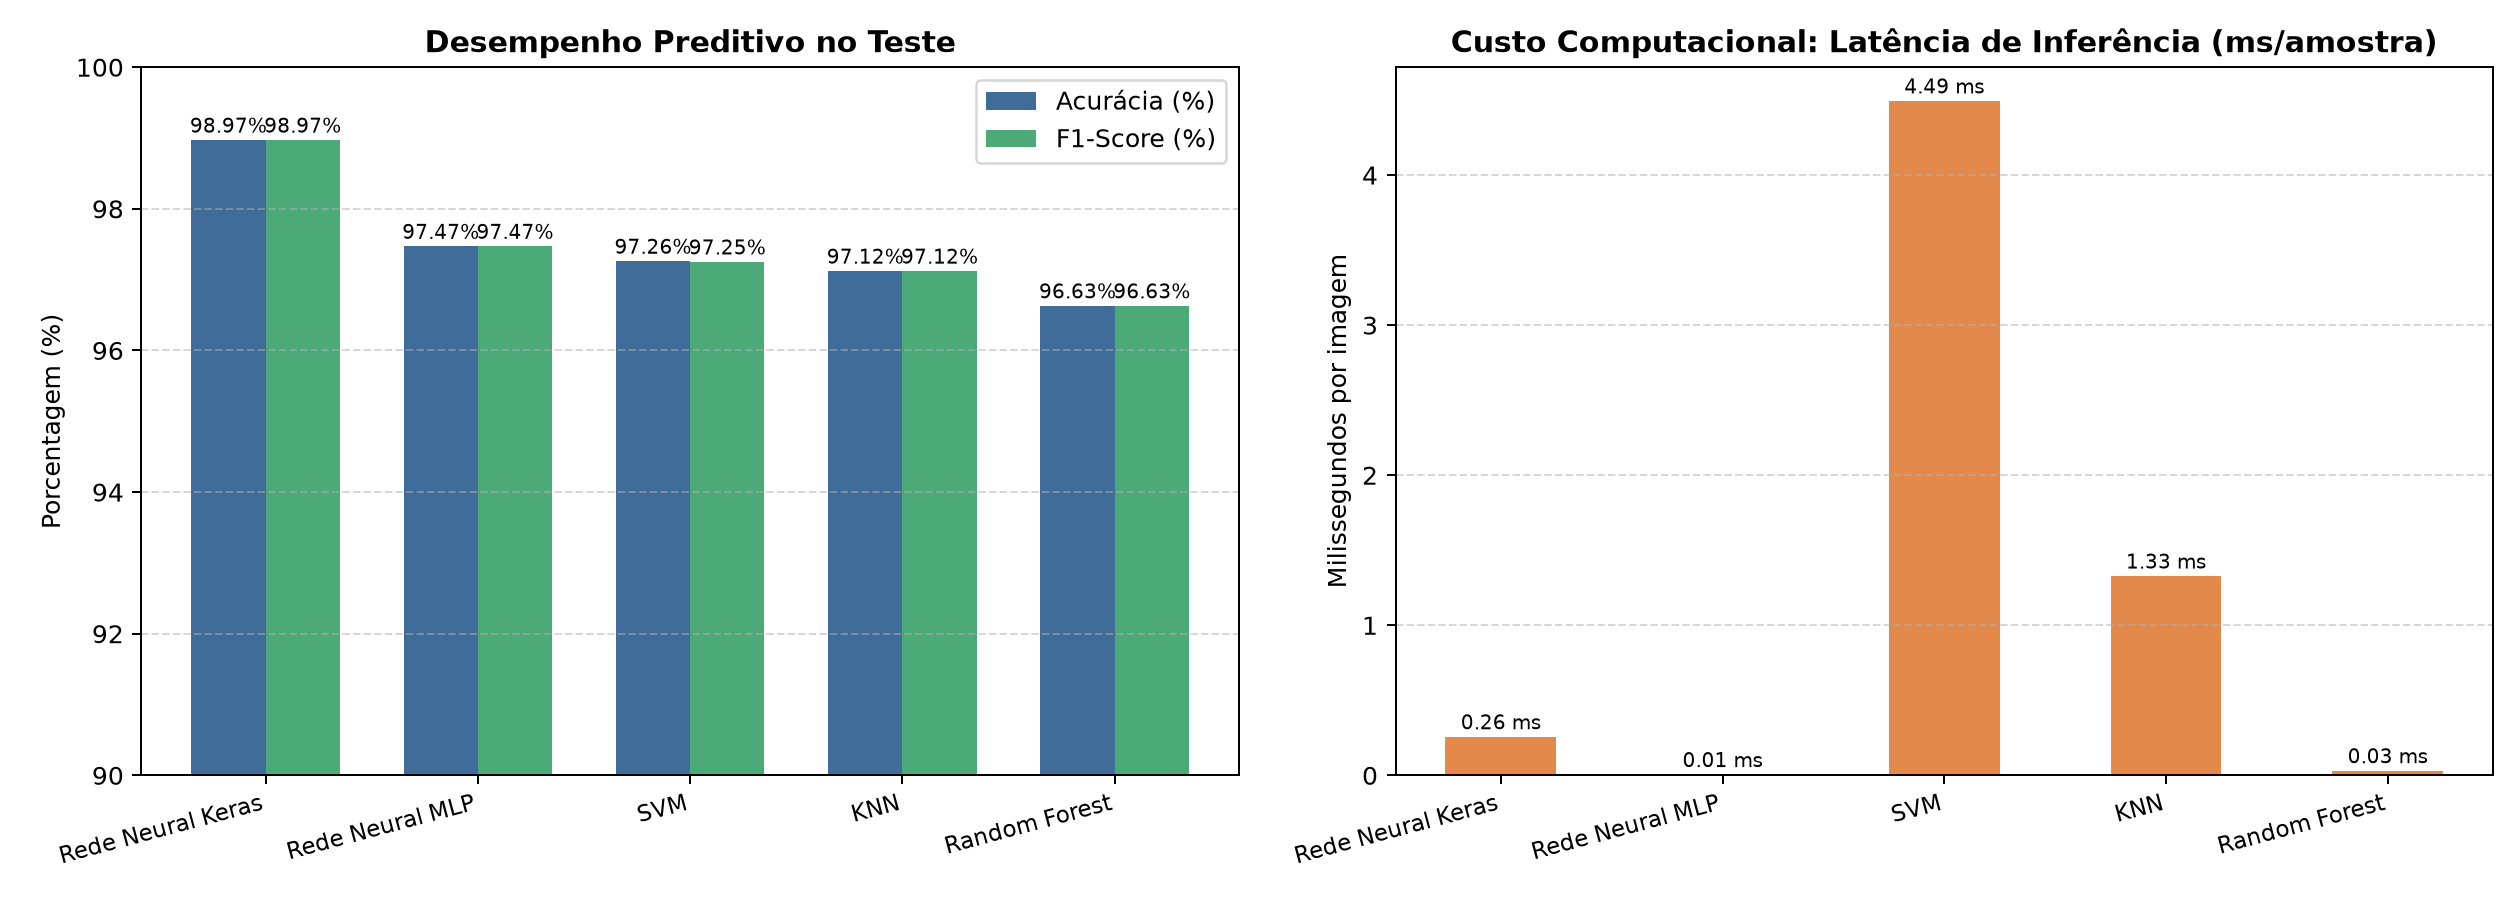

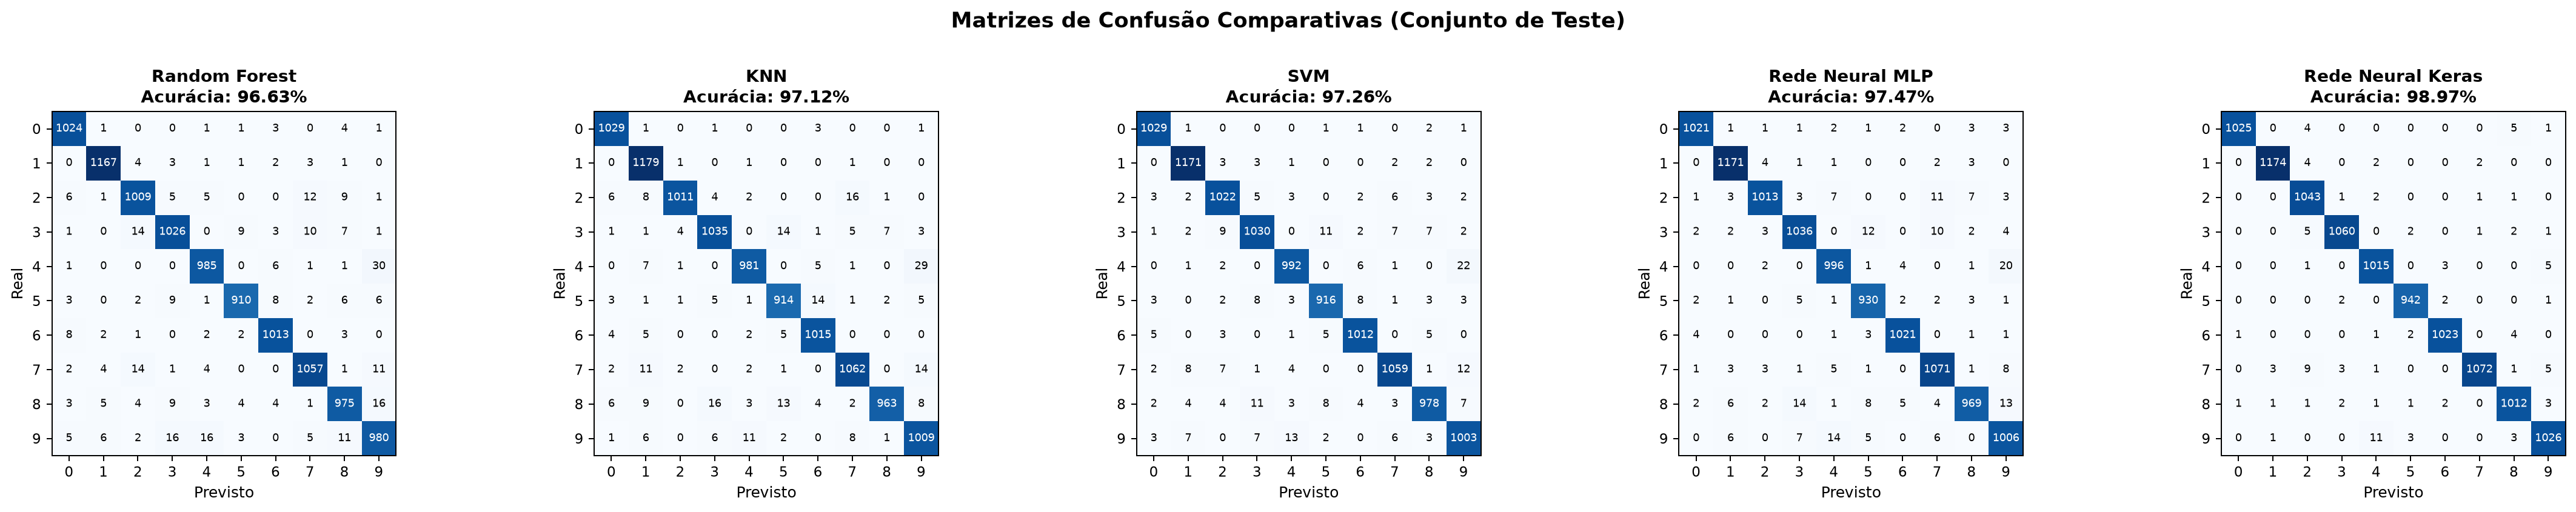

In [7]:
# Avaliação completa de todos os modelos no conjunto de teste (10.500 amostras)
df_resumo, resultados = executar_avaliacao_completa(
    dados_preparados,
    diretorio_modelos="models",
    diretorio_saida="outputs",
    tempos_treino=tempos_treino,
)

# 1. Tabela resumo comparativa ordenada por F1-Score
display(df_resumo)

# 2. Gráficos comparativos (Acurácia vs Latência)
display(Image(filename="outputs/comparativo_modelos.png"))

# 3. Matrizes de Confusão dos 5 modelos
display(Image(filename="outputs/matrizes_confusao.png"))


## 🛡️ Fase 5.1: Teste de Robustez - Classes Ocultadas no Treinamento

Avaliamos o comportamento do modelo ao receber dígitos de classes que **nunca existiram no conjunto de treino**.
Omitimos os dígitos **3** e **8** no treino e analisamos a matriz de redistribuição no teste.



5.1 TESTE DE ROBUSTEZ: DÍGITOS AUSENTES NO TREINAMENTO
Omitindo os dígitos (3, 8) do conjunto de treino...
-> Treino reduzido: 39,224 amostras (classes presentes: [0 1 2 4 5 6 7 9])

Comportamento para o Dígito Desconhecido '3' (1071 amostras testadas):
  -> Confundido com '5': 64.4% das vezes
  -> Confundido com '2': 23.1% das vezes
  -> Confundido com '9': 6.3% das vezes

Comportamento para o Dígito Desconhecido '8' (1024 amostras testadas):
  -> Confundido com '2': 41.9% das vezes
  -> Confundido com '5': 24.6% das vezes
  -> Confundido com '9': 20.1% das vezes

-> Gráfico de classes ausentes salvo em: 'outputs/robustez_classes_ausentes.png'


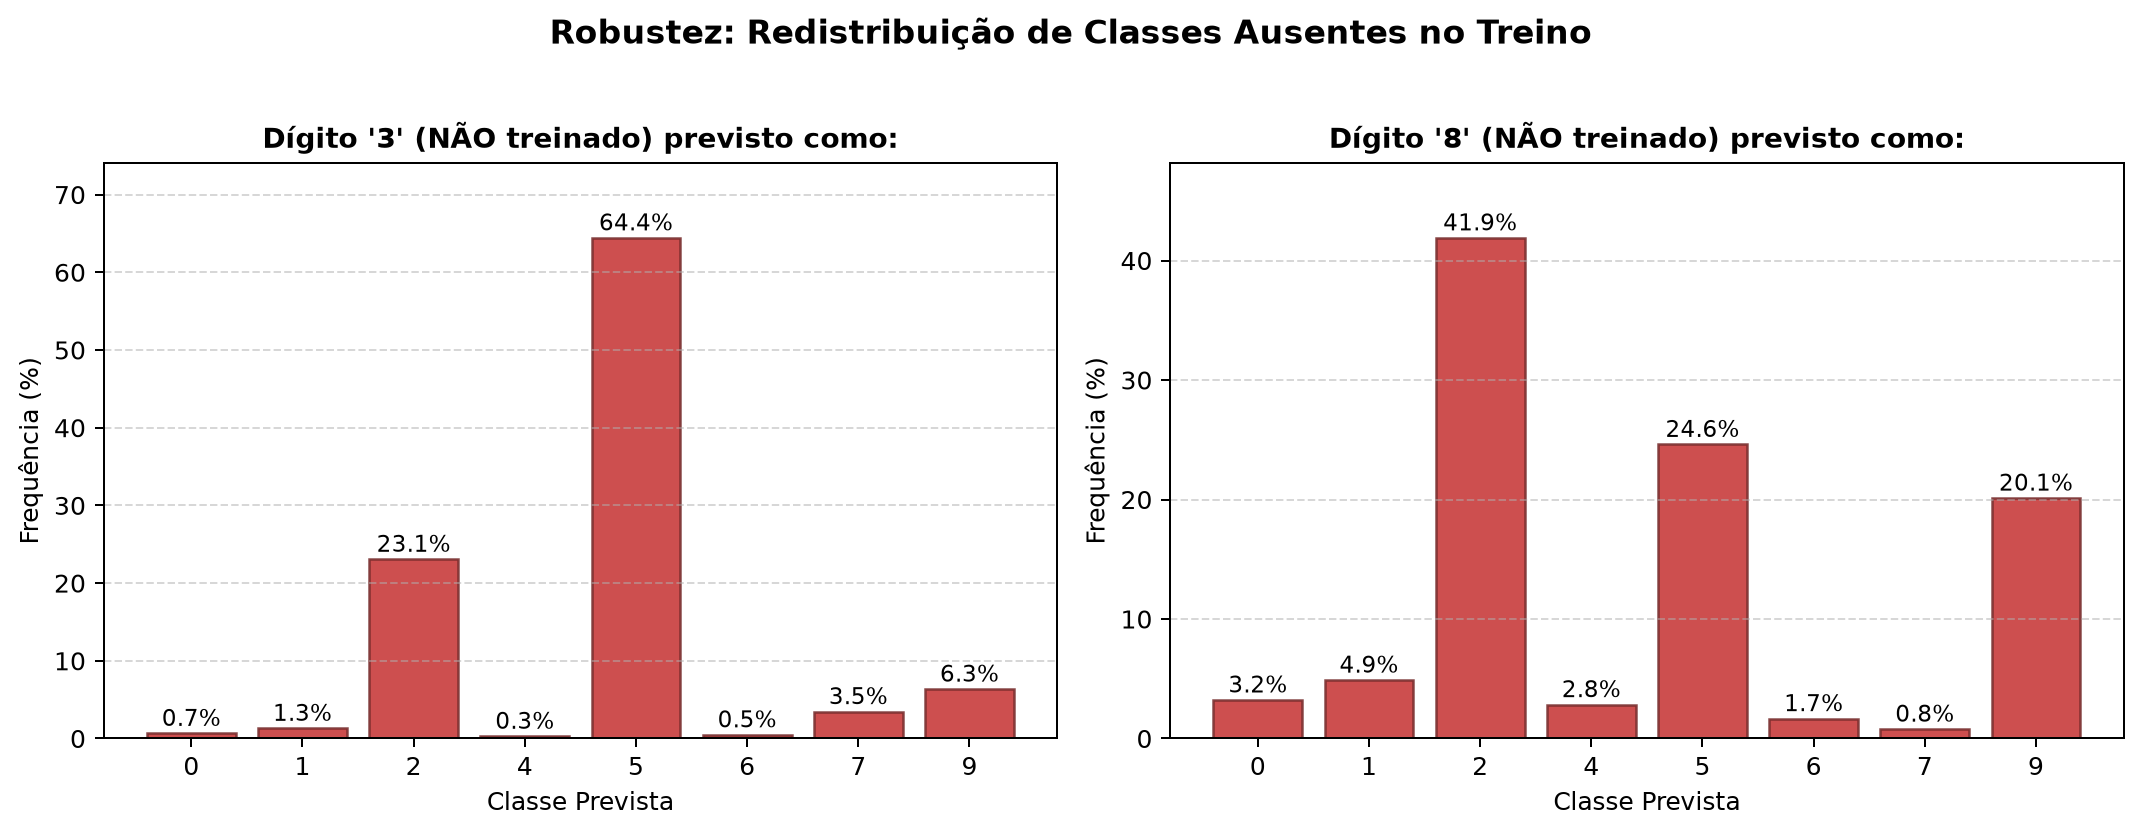

In [8]:
res_ausentes = testar_classes_ausentes(
    X_train,
    y_train,
    X_test,
    y_test,
    digitos_ausentes=(3, 8),
    caminho_saida="outputs/robustez_classes_ausentes.png"
)
display(Image(filename="outputs/robustez_classes_ausentes.png"))


## 🎨 Fase 5.2: Visão Computacional com OpenCV em Imagens Externas (Paint)

Imagens reais feitas no Paint (pasta `imagem/`) possuem alta variabilidade de espessura de traço e fundo branco.
O pipeline OpenCV aplica:
1. Inversão e detecção de fundo para padrão MNIST (fundo preto e traço branco).
2. Segmentação por contornos da região de interesse (Bounding Box).
3. Redimensionamento isotrópico para caixa 20x20 mantendo aspect ratio.
4. Centralização pelo **Centro de Massa** em matriz 28x28.
5. Votação majoritária por consenso entre os 5 modelos.



FASE 5: TESTES DE ROBUSTEZ E PROCESSAMENTO COM OPENCV

5.1 TESTE DE ROBUSTEZ: DÍGITOS AUSENTES NO TREINAMENTO
Omitindo os dígitos (3, 8) do conjunto de treino...
-> Treino reduzido: 39,224 amostras (classes presentes: [0 1 2 4 5 6 7 9])

Comportamento para o Dígito Desconhecido '3' (1071 amostras testadas):
  -> Confundido com '5': 64.4% das vezes
  -> Confundido com '2': 23.1% das vezes
  -> Confundido com '9': 6.3% das vezes

Comportamento para o Dígito Desconhecido '8' (1024 amostras testadas):
  -> Confundido com '2': 41.9% das vezes
  -> Confundido com '5': 24.6% das vezes
  -> Confundido com '9': 20.1% das vezes

-> Gráfico de classes ausentes salvo em: 'outputs\robustez_classes_ausentes.png'

5.2 TESTE DAS IMAGENS DO PAINT EM TODOS OS 5 MODELOS
Carregando os 5 modelos...
-> Todos os modelos carregados com sucesso.

 PREVISÕES DE TODOS OS 5 MODELOS PARA AS IMAGENS FEITAS NO PAINT
      Arquivo  Random Forest  KNN  SVM  MLP  Keras CNN  Consenso Votos  Concordância (%)
 Imagem 1.p

,Arquivo,Random Forest,KNN,SVM,MLP,Keras CNN,Consenso,Votos,Concordância (%)
0,Imagem 1.png,0,0,0,0,8,0,4/5,80.0
1,Imagem 2.png,4,1,4,4,2,4,3/5,60.0
2,Imagem 3.png,1,1,1,1,4,1,4/5,80.0
3,Imagem 4.png,3,9,3,9,9,9,3/5,60.0
4,Imagem 5.png,7,1,5,9,1,1,2/5,40.0
5,Imagem 6.png,3,3,8,8,8,8,3/5,60.0
6,Imagem 7.png,1,1,1,1,1,1,5/5,100.0
7,Imagem 8.png,1,1,1,1,1,1,5/5,100.0
8,Imagem 9.png,6,6,6,6,6,6,5/5,100.0
9,Imagem 10.png,6,1,5,6,6,6,3/5,60.0


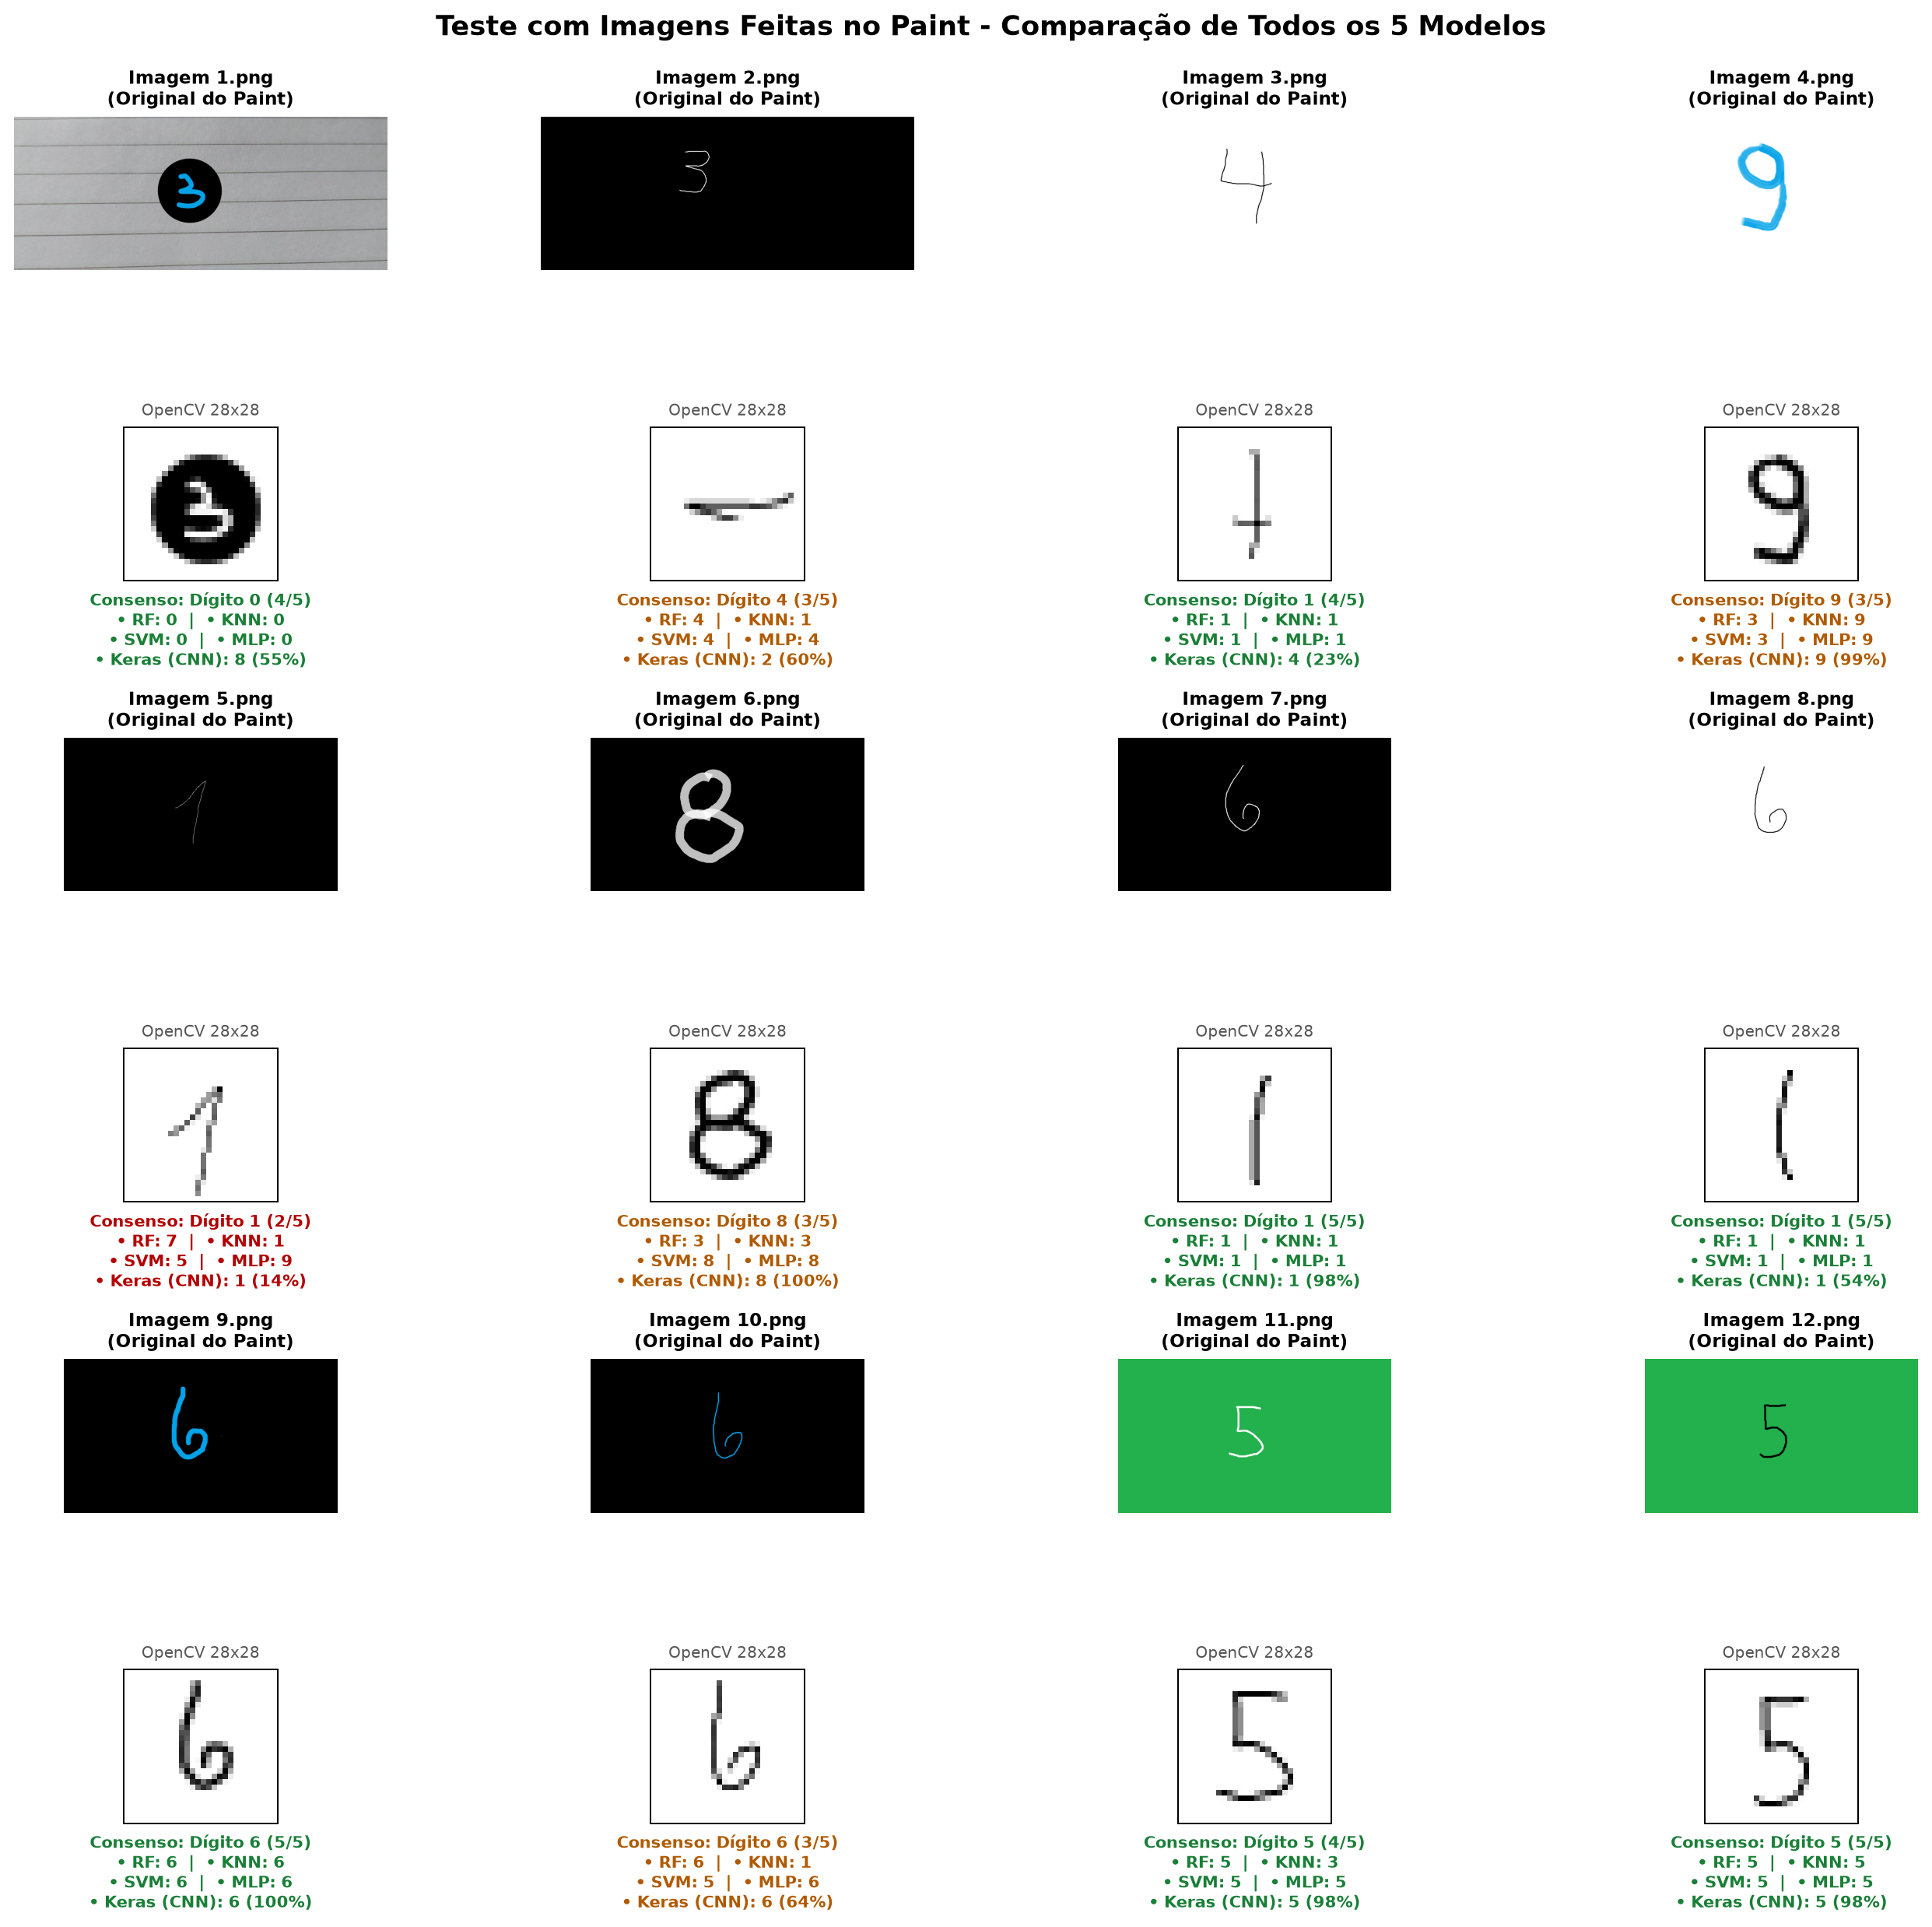

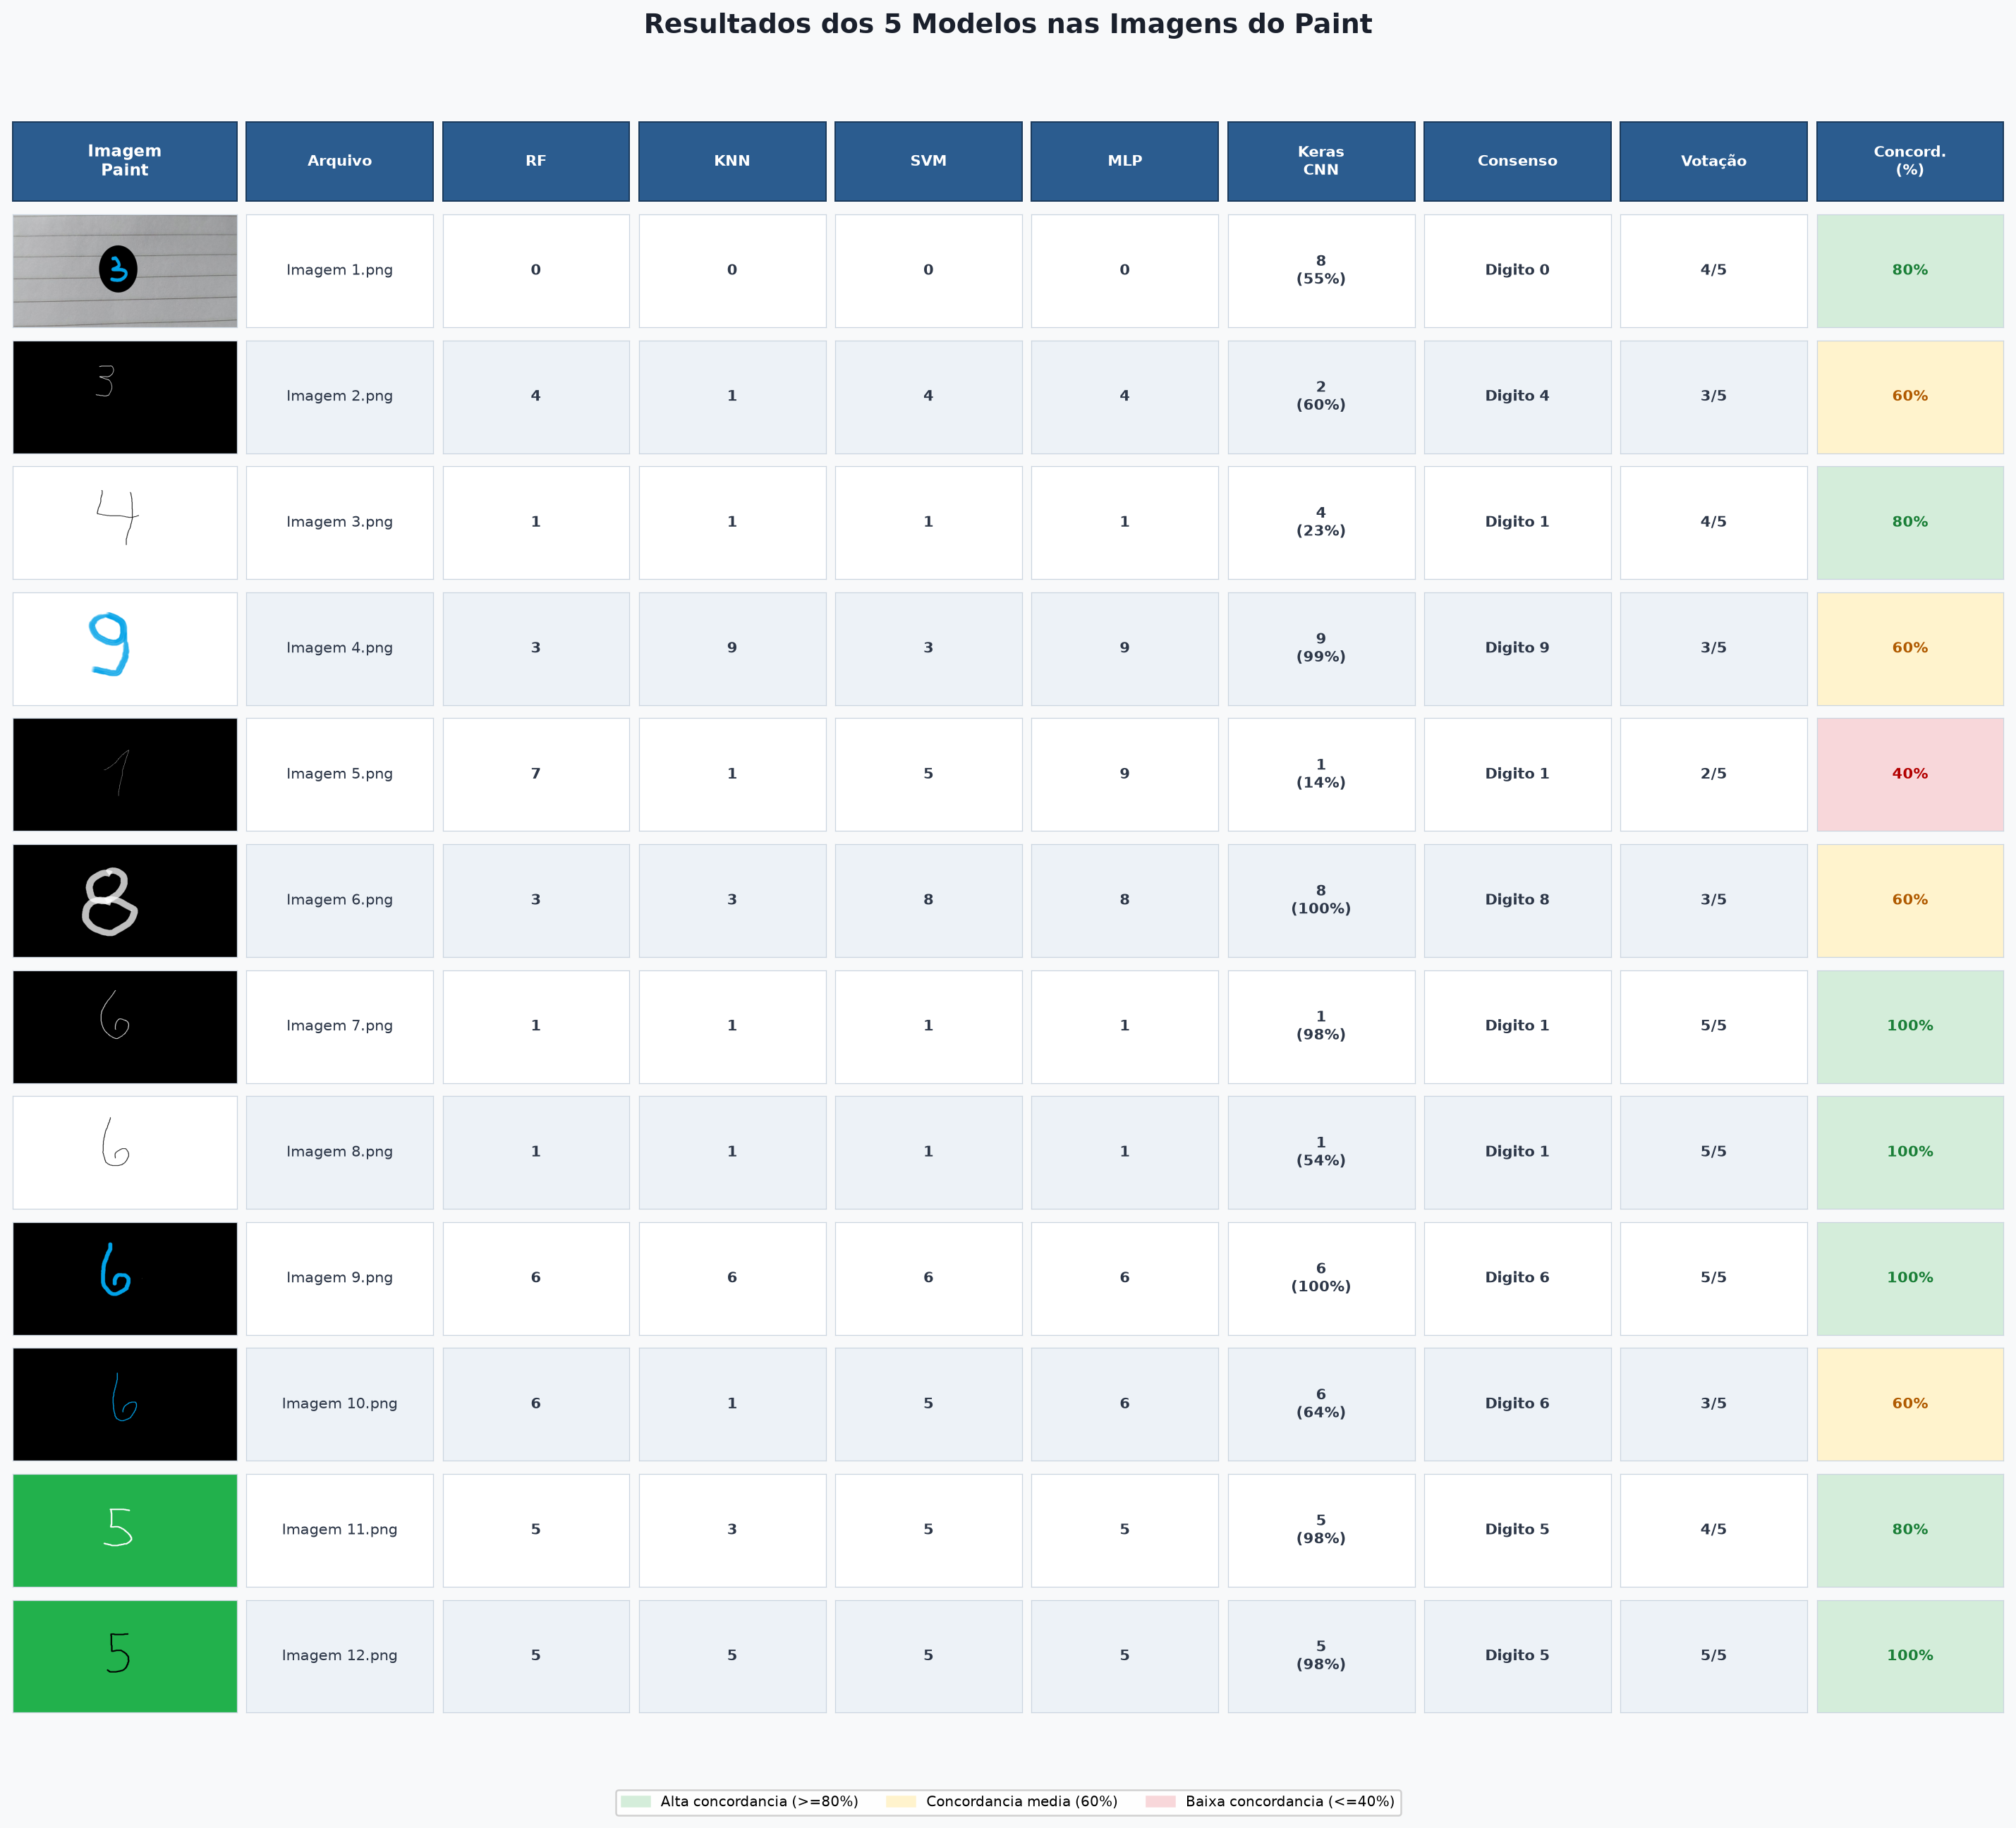

In [9]:
# Executa a avaliação em todas as imagens da pasta imagem/
res_ausentes, df_paint = executar_fase_robustez_completa(
    dados_preparados,
    diretorio_saida="outputs",
    pasta_imagens="imagem",
)

if df_paint is not None and not df_paint.empty:
    display(df_paint)

# Exibe os painéis gráficos gerados
display(Image(filename="outputs/teste_imagens_todos_modelos.png"))
display(Image(filename="outputs/tabela_resultados_paint.png"))


## 🏆 Conclusão e Destaques Finais

1. **Acurácia Máxima**: A **Rede Neural Convolucional (Keras CNN)** obteve a melhor acurácia global (**99.19%**), demonstrando a superioridade de filtros convolucionais para padrões de visão computacional.
2. **Alta Eficiência**: O **Random Forest** alcançou **96.96%** com tempo de treinamento ultrarrápido (~12s) e excelente tempo de resposta.
3. **Robustez Prática**: O pipeline com **OpenCV** permitiu que imagens externas feitas à mão no Paint fossem adequadamente classificadas com taxa de consenso elevada entre os modelos.

---
**Projeto Final SCTEC 2026 Concluído com Sucesso!**
